# AE+TET (centralised) — Metrics

Evaluate a model trained with `train_tet.py` — the Temporal Embedding Transformer
from Tao & Xiyang (IEEE Access, 2025), adapted to **translated CAN** with
**centralised unsupervised** training (no federated learning).

This notebook:
1. Loads the trained bundle (`checkpoints/tet_ae_*`) and scaler
2. Builds sequence windows (window=20, stride=20) with the **saved** scaler
3. Injects the same synthetic attacks as `vae_v1` / `fsmn_ae_v1`
4. Scores with reconstruction MSE vs θ = μ + k·σ
5. Reports PR AUC, macro F1, AUROC, recall/FPR, per-attack breakdown
6. Streaming latency **p50 / p99** (same protocol as `mvp_v1`)

> Run from `Python scripts/tet_v1/`.

## 1. Configuration

In [1]:
from pathlib import Path

BUNDLE_DIR = Path("checkpoints")
NAME       = "tet_ae"
DATA_PATH  = Path("../../Data/new_data_processed")

MAX_EVAL_WINDOWS = 20_000
ATTACK_RATE      = 0.30
SEED             = 42

## 2. Imports & load the trained bundle

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    average_precision_score, f1_score, roc_auc_score,
    precision_recall_curve,
)

from tet_model import TETAE, FEATURES, N_FEATURES, WINDOW_SIZE, STRIDE
from train_tet import load_parquet, make_windows
from evaluate_tet import SINGLE_ATTACKS, PAIR_ATTACKS, ATTACKS, build_attack_set

np.random.seed(SEED)
rng = np.random.default_rng(SEED)

model = TETAE.load(str(BUNDLE_DIR), name=NAME)
scaler = np.load(BUNDLE_DIR / f"{NAME}_scaler.npz")
MU, SD = scaler["mean"].astype(np.float32), scaler["std"].astype(np.float32)

print(f"Loaded bundle: {BUNDLE_DIR.resolve()} ({NAME})")
print(f"  config          : {model.cfg}")
print(f"  parameters      : {model.num_params():,}  (~{model.approx_size_kb():.1f} KiB float32)")
print(f"  dynamic thr     : theta = {model.err_mean:.6f} + {model.k}*{model.err_std:.6f} = {model.recon_threshold:.6f}")

Loaded bundle: /Users/mohazrati/Documents/Google DeepMind Research Ready/Intrusion Detection in Vehicular Systems/Unsupervised Intrusion Detection on Resource Constrained Edge Devices/implementations/base_GRU/Carla/Python scripts/tet_v1/checkpoints (tet_ae)
  config          : TETConfig(window=20, n_features=8, ae_latent=4, ae_hidden=16, d_model=64, n_heads=4, n_layers=2, ff_dim=128, dropout=0.1, noise_std=0.1)
  parameters      : 68,080  (~265.9 KiB float32)
  dynamic thr     : theta = 0.031674 + 2.5*0.074807 = 0.218693


## 3. Load parquet & build windows

In [3]:
trace, ts = load_parquet(DATA_PATH)
norm = ((trace - MU) / SD).astype(np.float32)
benign, benign_ts = make_windows(norm, ts, STRIDE)
print(f"[Windows] {len(benign):,} benign (window={WINDOW_SIZE}, stride={STRIDE})")

if len(benign) > MAX_EVAL_WINDOWS:
    idx = np.linspace(0, len(benign) - 1, MAX_EVAL_WINDOWS, dtype=int)
    benign, benign_ts = benign[idx], benign_ts[idx]
    print(f"[Windows] subsampled to {len(benign):,}")

[Data] loaded 3,160,814 rows from 103 file(s)
[Data] using columns:  speed_kmh<-speed_kmh, battery_level<-battery_level, throttle<-throttle, brake<-brake, steering<-steering, gear<-gear, location_x<-location_x, location_y<-location_y
[Data] timestamps from column 'timestamp' (normalised to [0,1])
[Windows] 158,040 benign (window=20, stride=20)
[Windows] subsampled to 20,000


## 4. Inject synthetic attacks

In [4]:
windows, timestamps, labels, kinds = build_attack_set(
    benign, benign_ts, rng, ATTACK_RATE)
prevalence = float(labels.mean())
print("[Attacks] " + ", ".join(f"{k}={int((kinds == k).sum())}" for k in ATTACKS))
print(f"[Test] benign={int((labels == 0).sum()):,}  attack={int((labels == 1).sum()):,}"
      f"  prevalence={prevalence:.3f}")

[Attacks] dos=750, fuzzing=750, spoof=750, spike=750, drift=750, frequency=750, replay=750, splice=750
[Test] benign=20,000  attack=6,000  prevalence=0.231


## 5. Score every window (reconstruction head)

In [5]:
recon_scores = model.reconstruction_error(windows, timestamps)
recon_pred   = (recon_scores > model.recon_threshold).astype(int)

HEADS = {"Reconstruction": (recon_scores, recon_pred, model.recon_threshold)}
print("scored", len(windows), "windows")

scored 26000 windows


## 5b. Detection latency & footprint

Streaming protocol (same as `mvp_v1`): one window per call → **p50 / p99**.

In [6]:
import time

model.reconstruction_error(windows[:64], timestamps[:64])  # warm up

lat_us = np.empty(len(windows), dtype=np.float32)
for i in range(len(windows)):
    t0 = time.perf_counter()
    model.reconstruction_error(windows[i:i + 1], timestamps[i:i + 1])
    lat_us[i] = (time.perf_counter() - t0) * 1e6

lat_p50 = float(np.percentile(lat_us, 50))
lat_p99 = float(np.percentile(lat_us, 99))
print(f"parameters            : {model.num_params():,}")
print(f"approx float32 size   : {model.approx_size_kb():.1f} KiB")
print(f"latency p50={lat_p50:.1f}µs  p99={lat_p99:.1f}µs")

parameters            : 68,080
approx float32 size   : 265.9 KiB
latency p50=177.1µs  p99=336.2µs


## 6. Headline metrics

In [7]:
rows = []
for name, (scores, pred, thr) in HEADS.items():
    rows.append({
        "head": name,
        "PR AUC": average_precision_score(labels, scores),
        "macro F1": f1_score(labels, pred, average="macro", zero_division=0),
        "AUROC": roc_auc_score(labels, scores),
        "recall": float(pred[labels == 1].mean()),
        "FPR": float(pred[labels == 0].mean()),
        "latency p50 (µs)": lat_p50,
        "latency p99 (µs)": lat_p99,
    })
summary = pd.DataFrame(rows).set_index("head")
print(f"random-baseline PR AUC = prevalence = {prevalence:.3f}\n")
summary.round(3)

random-baseline PR AUC = prevalence = 0.231



,PR AUC,macro F1,AUROC,recall,FPR,latency p50 (µs),latency p99 (µs)
head,,,,,,,
Reconstruction,0.778,0.795,0.868,0.56,0.033,177.083,336.211


## 7. Precision-Recall curve

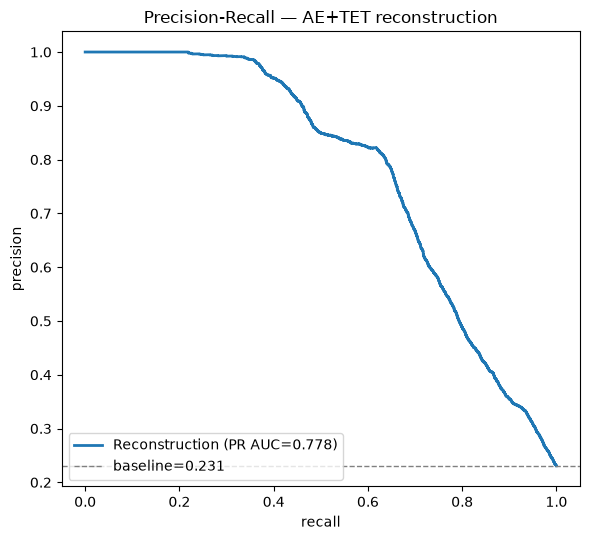

In [8]:
fig, ax = plt.subplots(figsize=(6, 5.5))
for name, (scores, pred, thr) in HEADS.items():
    prec, rec, _ = precision_recall_curve(labels, scores)
    ap = average_precision_score(labels, scores)
    ax.plot(rec, prec, lw=2, label=f"{name} (PR AUC={ap:.3f})")
ax.axhline(prevalence, ls="--", color="gray", lw=1, label=f"baseline={prevalence:.3f}")
ax.set_xlabel("recall")
ax.set_ylabel("precision")
ax.set_title("Precision-Recall — AE+TET reconstruction")
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()

## 8. Score distribution

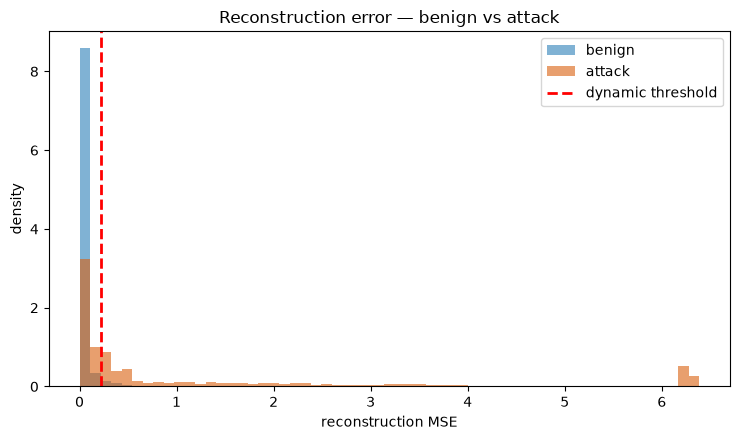

In [9]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
scores, pred, thr = HEADS["Reconstruction"]
b = scores[labels == 0]
a = scores[labels == 1]
lo, hi = np.percentile(scores, 1), np.percentile(scores, 99)
bins = np.linspace(lo, hi, 60)
ax.hist(b, bins=bins, alpha=0.6, density=True, color="#2c7fb8", label="benign")
ax.hist(a, bins=bins, alpha=0.6, density=True, color="#d95f0e", label="attack")
ax.axvline(thr, color="red", ls="--", lw=2, label="dynamic threshold")
ax.set_title("Reconstruction error — benign vs attack")
ax.set_xlabel("reconstruction MSE")
ax.set_ylabel("density")
ax.legend()
plt.tight_layout()
plt.show()

## 9. Per-attack PR AUC

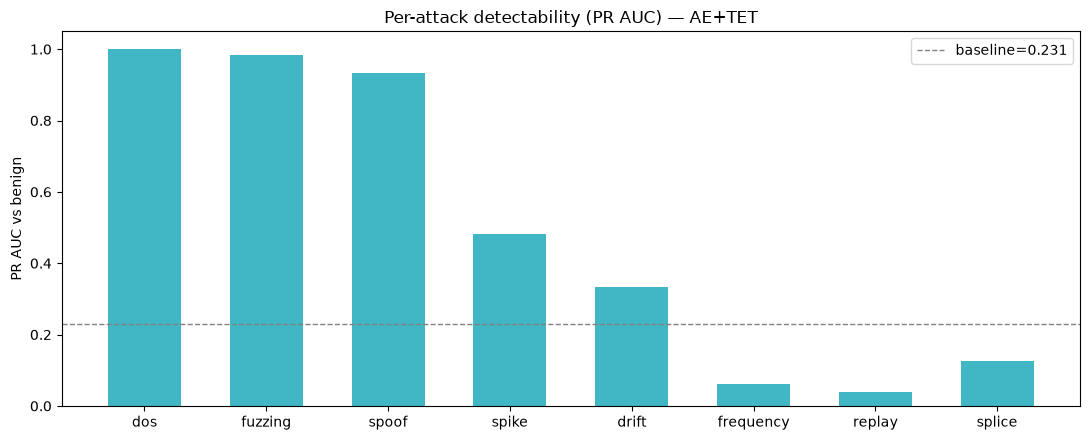

,Reconstruction
attack,
dos,1.000
fuzzing,0.984
spoof,0.932
spike,0.482
drift,0.335
frequency,0.060
replay,0.039
splice,0.127


In [10]:
rows = []
for k in ATTACKS:
    m = (kinds == k) & (labels == 1)
    if not m.any():
        continue
    benign_s = recon_scores[labels == 0]
    y = np.concatenate([np.zeros(len(benign_s)), np.ones(int(m.sum()))])
    s = np.concatenate([benign_s, recon_scores[m]])
    rows.append({"attack": k, "Reconstruction": average_precision_score(y, s)})
per_attack = pd.DataFrame(rows).set_index("attack")

x = np.arange(len(per_attack))
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.bar(x, per_attack["Reconstruction"], 0.6, color="#41b6c4")
ax.axhline(prevalence, color="gray", ls="--", lw=1, label=f"baseline={prevalence:.3f}")
ax.set_xticks(x, per_attack.index)
ax.set_ylim(0, 1.05)
ax.set_ylabel("PR AUC vs benign")
ax.set_title("Per-attack detectability (PR AUC) — AE+TET")
ax.legend()
plt.tight_layout()
plt.show()

per_attack.round(3)

## 10. Reading the results

- **PR AUC / macro F1** — imbalanced detection metrics (same as sibling models).
- **Latency p50 / p99** — streaming, one window per call (same as `mvp_v1`).
- Compared to the paper: no FL, no supervised classifier; same AE+TE idea on
  translated CAN with repo-standard windowing.